In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

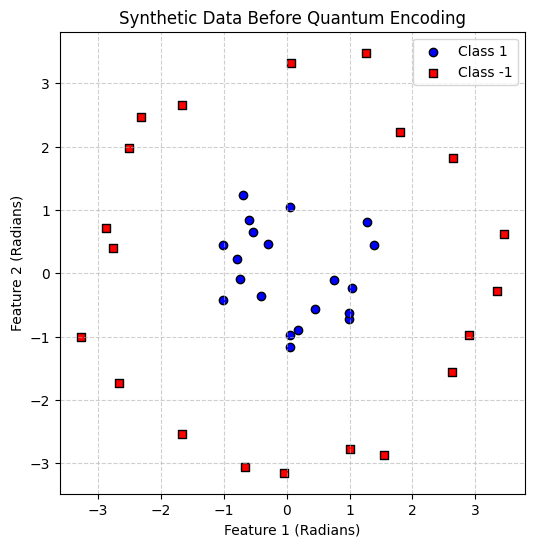

In [ ]:
# Synthetic Data Generation
X, y = make_circles(n_samples=40, noise=0.1, factor=0.3, random_state=42)

y = np.where(y == 0, -1, 1)
X_scaled = X * np.pi

plt.figure(figsize=(6, 6))
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1],
            color="blue", marker='o', edgecolors='k', label="Class 1")
plt.scatter(X_scaled[y == -1, 0], X_scaled[y == -1, 1],
            color="red", marker='s', edgecolors='k', label="Class -1")
plt.title("Synthetic Data Before Quantum Encoding")
plt.xlabel("Feature 1 (Radians)")
plt.ylabel("Feature 2 (Radians)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# ----------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

In [21]:
# Quantum Kernel
num_qubits = 2
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev)
def feature_map(x):
    qml.AngleEmbedding(x, wires=range(num_qubits))
    qml.CNOT(wires=[0, 1])
    qml.RZ(x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(num_qubits))

def qsvm_kernel(x1, x2):
    return kernel_circuit(x1, x2)[0]

def compute_kernel_matrix(A, B):
    matrix = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            matrix[i, j] = qsvm_kernel(A[i], B[j])
    return matrix

In [15]:
X_train[0]

array([2.6442833 , 1.82109756])

In [22]:
print(qml.draw(feature_map)(X_train[0]))

0: ─╭AngleEmbedding(M0)─╭●───────────╭●─┤  
1: ─╰AngleEmbedding(M0)─╰X──RZ(4.82)─╰X─┤  

M0 = 
[2.6442833  1.82109756]


In [9]:
# Train SVM
print("Computing training kernel matrix... (This may take a minute)")
K_train = compute_kernel_matrix(X_train, X_train)

svm = SVC(kernel='precomputed')
svm.fit(K_train, y_train)

print("Computing testing kernel matrix...")
K_test = compute_kernel_matrix(X_test, X_train)
accuracy = svm.score(K_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Computing training kernel matrix... (This may take a minute)
Computing testing kernel matrix...
Test Accuracy: 100.00%


Evaluating grid points for decision boundary...


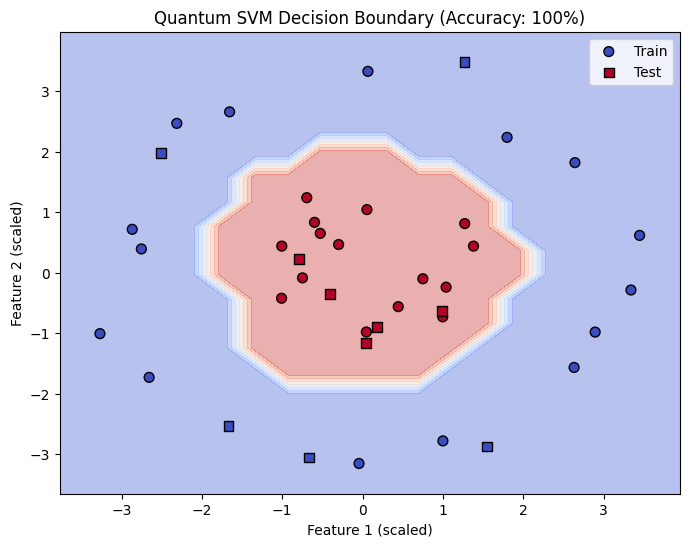

In [10]:
# Plots
print("Evaluating grid points for decision boundary...")
grid_res = 20
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                     np.linspace(y_min, y_max, grid_res))

grid_points = np.c_[xx.ravel(), yy.ravel()]

K_grid = compute_kernel_matrix(grid_points, X_train)

Z = svm.predict(K_grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)

scatter_train = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                            cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=50, label="Train")
scatter_test = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                           cmap=plt.cm.coolwarm, edgecolors='k', marker='s', s=50, label="Test")

plt.title(f"Quantum SVM Decision Boundary (Accuracy: {accuracy*100:.0f}%)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.show()